In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
import os
from data.loader import *
import h5py
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
from utils.metrics import *
from utils.tools import smooth_predictions

In [ ]:
method = 'videopose'
base_dir = "./results/class"
splits = list(range(7))

In [ ]:
# Postprocessing function to smooth predictions 
def load_predictions_and_labels(method, split):
    file_path = os.path.join(base_dir, f"{method}_split{split}.npy")
    data = np.load(file_path, allow_pickle=True)
    print(f'Loading data from: {file_path}')
    return get_data(data)

for split in splits:
    pred, actual = load_predictions_and_labels('videopose', split)

    result_path = f'./results/class/videopose_smooth{split}.npy'
    pred = smooth_predictions(pred, smoothing_window=5, zero_replacement_window=30)

    results = np.stack((pred, actual), axis=1)
    np.save(result_path, results)

In [3]:
# classification results
metrics = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'segment_f1': []}
task = 'class'

# Compute metrics
for split in splits:
    file_path = os.path.join(base_dir, task, method, f"{method}_smooth{split}.npy")
    print(f"Loading data from: {file_path}")
    data = np.load(file_path, allow_pickle=True)
    pred, actual = get_data(data, task)

    # Adjust length for videopose method
    pred = pred[121:]
    actual = actual[121:]

    acc, f1, prec, rec, segf1 = performance_metrics(actual, pred)
    metrics['accuracy'].append(acc)
    metrics['f1'].append(f1)
    metrics['precision'].append(prec)
    metrics['recall'].append(rec)
    metrics['segment_f1'].append(segf1)

# Print summary
print(f"\n=== Performance Summary for {method} ===")
for metric, values in metrics.items():
    values = np.array(values)
    mean = np.round(np.mean(values), 4)
    std = np.round(np.std(values), 4)
    print(f"{metric.capitalize()}: {mean} ± {std}")

Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth0.npy
Weighted average metrics:
Accuracy: 0.8925
F1-Score: 0.8932
Precision: 0.8986
Recall: 0.8925
F1@50: 0.929
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth1.npy
Weighted average metrics:
Accuracy: 0.768
F1-Score: 0.7422
Precision: 0.8117
Recall: 0.768
F1@50: 0.8192
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth2.npy
Weighted average metrics:
Accuracy: 0.8799
F1-Score: 0.8788
Precision: 0.893
Recall: 0.8799
F1@50: 0.9282
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth3.npy
Weighted average metrics:
Accuracy: 0.8865
F1-Score: 0.8855
Precision: 0.89
Recall: 0.8865
F1@50: 0.9394
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth4.npy
Weighted average metrics:
Accuracy: 0.9062
F1-Score: 0.9051
Precision: 0.9105
Recall: 0.9062
F1@50: 0.9

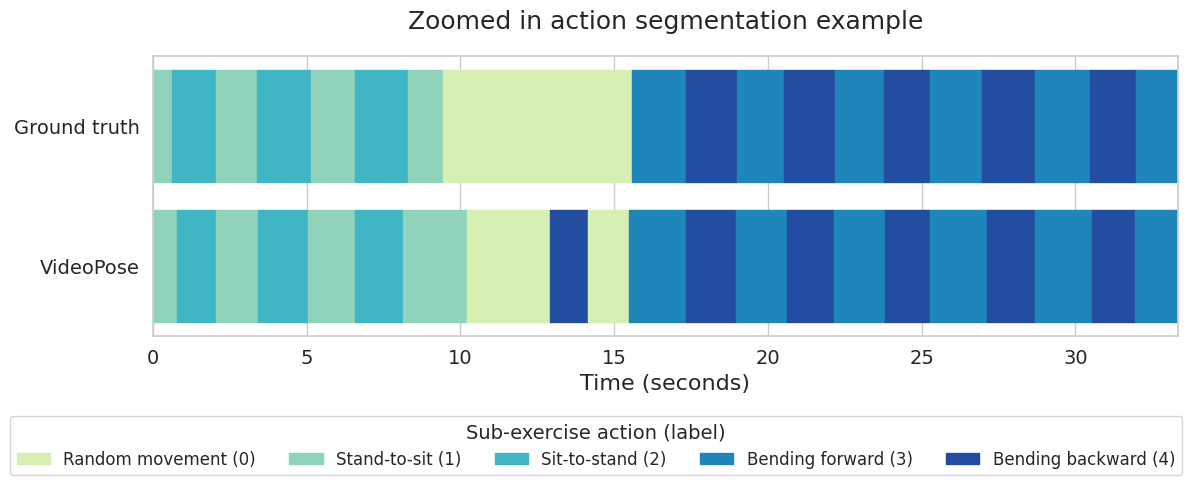

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

# Define paths and new method labels
method_labels = ["Ground truth", "VideoPose"] 
sampling_frequency = 30  # Frames per second
start = 2000
end = 3000
actual_ = actual[start:end]
pred_ = pred[start:end]

actual_labels = actual_
predictions = pred_

# Create data structure
data = {
    "VideoPose": pred_,
}
actual_labels = actual_

# Determine all unique labels in both prediction and ground truth
unique_labels = sorted(set(actual_labels) | set(pred_))
cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.2, 0.8, len(unique_labels))))
colors = {label: cmap(i / (len(unique_labels) - 1)) for i, label in enumerate(unique_labels)}

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))
y_positions = np.arange(len(method_labels))[::-1]

def plot_bars(ax, labels, y_pos, color_map, sampling_rate):
    current_start = 0
    for i in range(len(labels)):
        if i == len(labels) - 1 or labels[i] != labels[i + 1]:
            rect = Rectangle(
                (current_start / sampling_rate, y_pos - 0.4),
                (i - current_start + 1) / sampling_rate,
                0.8,
                color=color_map[labels[i]],
            )
            ax.add_patch(rect)
            current_start = i + 1

# Plot ground truth
plot_bars(ax, actual_labels, y_positions[0], colors, sampling_frequency)

# Plot predictions
plot_bars(ax, pred_, y_positions[1], colors, sampling_frequency)

# Axis settings
max_time = len(actual_labels) / sampling_frequency
ax.set_xlim(0, max_time)
ax.set_yticks(y_positions)
ax.set_yticklabels(method_labels, fontsize=14)
ax.set_ylim(y_positions.min() - 0.5, y_positions.max() + 0.5)
ax.set_xlabel("Time (seconds)", fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_title("Zoomed in action segmentation example", fontsize=18, pad=20)

# Label mapping
exercise_labels = {
    0: 'Random movement',
    1: 'Stand-to-sit',
    2: 'Sit-to-stand',
    3: 'Bending forward',
    4: 'Bending backward'
}
legend_patches = [
    Rectangle((0, 0), 1, 1, color=colors[key], label=f"{exercise_labels.get(key, 'Unknown')} ({key})")
    for key in unique_labels
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=len(exercise_labels),
    title="Sub-exercise action (label)",
    fontsize=12,
    title_fontsize=14,
    bbox_to_anchor=(0.5, 0.08),
)

plt.tight_layout(rect=[0, 0.2, 1, 0.9])
plt.savefig("results/figures/zoomed_class.svg", format="svg")
plt.show()

In [8]:
import numpy as np
from collections import defaultdict

def segment_f1_score_per_class(recognized, ground_truth, overlap=0.5):
    p_label, p_start, p_end = get_labels_start_end_time(recognized)
    y_label, y_start, y_end = get_labels_start_end_time(ground_truth)

    classes = set(p_label).union(set(y_label))
    f1_scores = {}

    for cls in classes:
        # Get predicted segments of this class
        cls_p_idx = [i for i, label in enumerate(p_label) if label == cls]
        cls_y_idx = [i for i, label in enumerate(y_label) if label == cls]

        cls_p_start = [p_start[i] for i in cls_p_idx]
        cls_p_end = [p_end[i] for i in cls_p_idx]
        cls_y_start = [y_start[i] for i in cls_y_idx]
        cls_y_end = [y_end[i] for i in cls_y_idx]

        tp = 0
        fp = 0
        hits = np.zeros(len(cls_y_idx))

        if len(cls_y_idx) == 0:
            fp = len(cls_p_idx)
        else:
            for j in range(len(cls_p_idx)):
                intersection = np.minimum(cls_p_end[j], cls_y_end) - np.maximum(cls_p_start[j], cls_y_start)
                union = np.maximum(cls_p_end[j], cls_y_end) - np.minimum(cls_p_start[j], cls_y_start)
                IoU = intersection / union
                IoU = np.where(np.array(IoU) < 0, 0, IoU)  # eliminate negatives
                idx = IoU.argmax()

                if IoU[idx] >= overlap and not hits[idx]:
                    tp += 1
                    hits[idx] = 1
                else:
                    fp += 1

        fn = len(cls_y_idx) - np.sum(hits)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        f1_scores[cls] = f1

    return f1_scores


In [20]:
f1_per_class_dict = defaultdict(list)

for split in splits:
    file_path = os.path.join(base_dir, task, method, f"{method}_smooth{split}.npy")
    print(f"Loading data from: {file_path}")

    data = np.load(file_path, allow_pickle=True)
    pred, actual = get_data(data, task)

    # Adjust length for VideoPose
    pred = pred[121:]
    actual = actual[121:]

    f1_scores = segment_f1_score_per_class(pred, actual, overlap=0.5)

    for cls in range(15):
        if cls in f1_scores:
            f1_per_class_dict[cls].append(f1_scores[cls])
        else:
            f1_per_class_dict[cls].append(0.0)  # or np.nan if you prefer

Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth0.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth1.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth2.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth3.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth4.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth5.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth6.npy


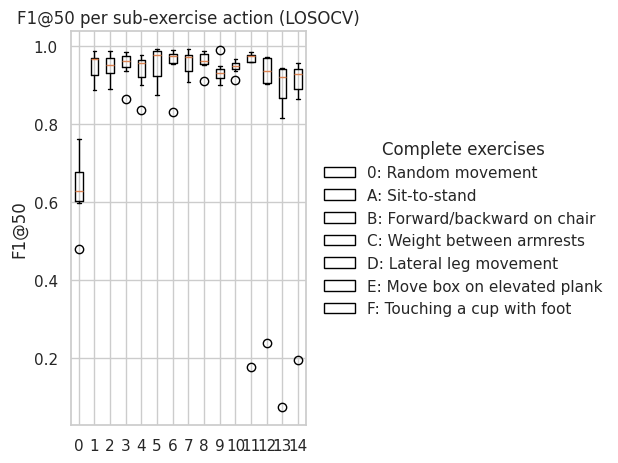

In [30]:
labels = list(f1_per_class_dict.keys())
data = [f1_per_class_dict[k] for k in labels]

from matplotlib.patches import Patch

# Define your class label mappings
label_mapping = {
    "0": "Random movement",
    "A": "Sit-to-stand",
    "B": "Forward/backward on chair",
    "C": "Weight between armrests",
    "D": "Lateral leg movement",
    "E": "Move box on elevated plank",
    "F": "Touching a cup with foot"
}

plt.boxplot(data, labels=labels)
#plt.xlabel("Exercise Class")
plt.ylabel("F1@50")
plt.title(f"F1@50 per sub-exercise action (LOSOCV)")

# Create dummy handles for the legend
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label=f"{k}: {v}")
    for k, v in label_mapping.items()
]

# Add the legend outside the plot
plt.legend(
    handles=legend_elements,
    title="Complete exercises",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig("results/figures/per_ex_class.svg", format="svg")
plt.show()

In [3]:
# regression metrics
overall_maes, per_joint_maes, per_coord_maes, correlations = [], [], [], []
overall_rmses, per_joint_rmses, per_coord_rmses = [], [], []

def print_per_joint_stats(metric_array, name="MAE"):
    print(f"\nPer-Joint {name} (mean ± std across folds):")
    array = np.stack([x.squeeze() for x in metric_array], axis=0)
    mean_vals = np.mean(array, axis=0)
    std_vals = np.std(array, axis=0)
    for j, (m, s) in enumerate(zip(mean_vals, std_vals)):
        print(f"Joint {j}: {float(m):.4f} ± {float(s):.4f}")

def print_per_coordinate_stats(metric_array, name="MAE", coord_names=('X', 'Y', 'Z')):
    """
    Prints the mean ± std per coordinate (e.g., X, Y, Z) across folds.

    Parameters:
    - metric_array: list or np.ndarray of shape (n_folds, 3)
    - name: str, name of the metric (e.g., "MAE", "RMSE")
    - coord_names: tuple or list of coordinate labels
    """
    print(f"\nPer-Coordinate {name} (mean ± std across folds):")
    metric_array = np.stack(metric_array, axis=0)  # shape: (folds, 3)
    mean_vals = np.mean(metric_array, axis=0)
    std_vals = np.std(metric_array, axis=0)
    for i, (m, s) in enumerate(zip(mean_vals, std_vals)):
        print(f"{coord_names[i]}: {m:.4f} ± {s:.4f}")

task = 'reg'
joint_mask = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=np.float32)
#joint_mask = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float32)
for split in splits:
    file_path = os.path.join(base_dir, task, method, f"{method}_split{split}.npy")
    print(f"Loading data from: {file_path}")
    data = np.load(file_path, allow_pickle=True)
    pred, actual = get_data(data, task)

    overall_mae = compute_mae_videopose(pred, actual, joint_mask, mode="overall")
    per_joint_mae = compute_mae_videopose(pred, actual, joint_mask, mode="per_joint")
    per_coord_mae = compute_mae_videopose(pred, actual, joint_mask, mode="per_coordinate")
    overall_rmse = compute_mae_videopose(pred, actual, joint_mask, mode="overall_rmse")
    per_coord_rmse = compute_mae_videopose(pred, actual, joint_mask, mode="per_coordinate_rmse")
    per_joint_rmse = compute_mae_videopose(pred, actual, joint_mask, mode="per_joint_rmse")

    # Correlation
    corr = compute_correlation(pred, actual)

    # Store
    overall_maes.append(overall_mae)
    overall_rmses.append(overall_rmse)
    per_joint_maes.append(per_joint_mae)
    per_coord_maes.append(per_coord_mae)
    per_joint_rmses.append(per_joint_rmse)
    per_coord_rmses.append(per_coord_rmse)
    correlations.append(corr)

# === Summary Output ===
print(f"\n=== Mean Angular Error Summary for '{method}' ===")
print(f"Overall MAE: {np.mean(overall_maes):.4f} ± {np.std(overall_maes):.4f}")
print(f"Overall RMSE: {np.mean(overall_rmses):.4f} ± {np.std(overall_rmses):.4f}")
print(f"Correlation: {np.mean(correlations):.4f} ± {np.std(correlations):.4f}")

print_per_joint_stats(per_joint_maes, name="MAE")
print_per_joint_stats(per_joint_rmses, name="RMSE")

print_per_coordinate_stats(per_coord_maes, name="MAE")
print_per_coordinate_stats(per_coord_rmses, name="RMSE")


Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split0.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split1.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split2.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split3.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split4.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split5.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split6.npy

=== Mean Angular Error Summary for 'videopose' ===
Overall MAE: 7.7076 ± 0.9148
Overall RMSE: 13.3254 ± 2.3791
Correlation: 0.7475 ± 0.0456

Per-Joint MAE (mean ± std across folds):
Joint 0: 3.6331 ± 0.9920
Joint 1: 1.2157 ± 0.3225
Joint 2: 4.0074 ± 0.2894
Joint 3: 0.0000 ± 0.0000
Joint 4: 0.0000 ± 0.0000
Joint 5: 0.0000 ± 0.0000
Joint 6: 0.0000 ± 0.000

In [39]:
def compute_rmse(pred_flat, actual_flat):
    return np.sqrt(np.mean((pred_flat - actual_flat) ** 2))

Loading class data from: /data/leuven/365/vsc36565/WZC/results/class/videopose/videopose_smooth6.npy
Loading reg data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split6_win.npy


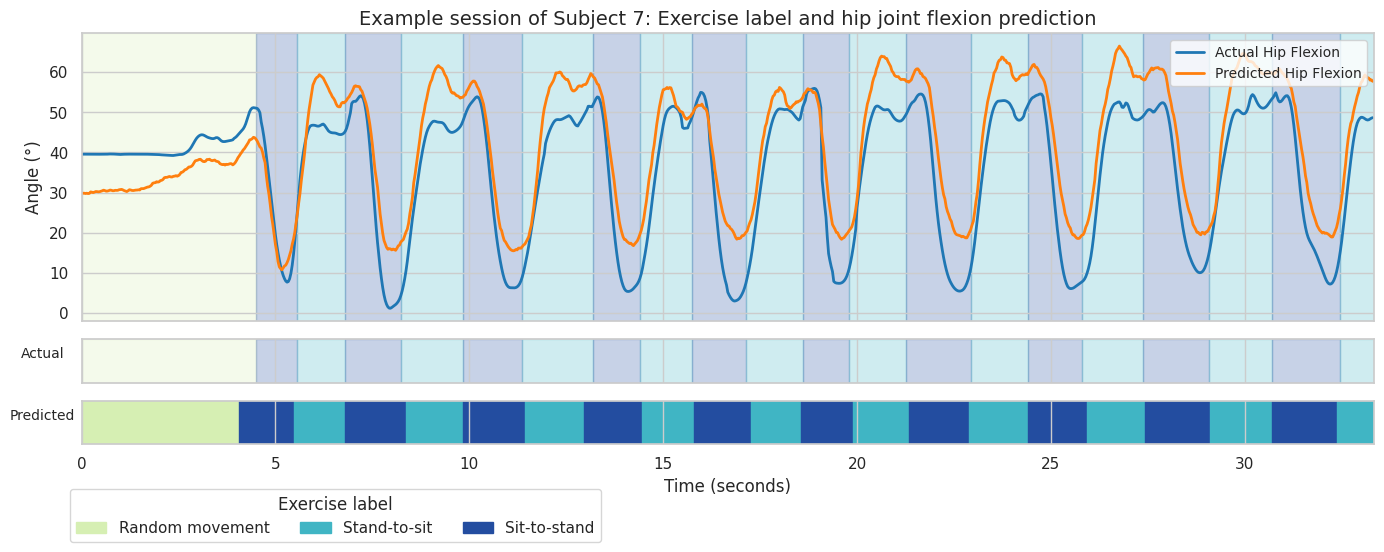

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

# --- Parameters ---
base_dir = "/data/leuven/365/vsc36565/WZC/results"
sampling_frequency = 30
split = 6
method = "videopose"
frame_start, frame_end = 500, 1500
joint_id, axis_id = 11, 2

# --- Load classification results ---
task = 'class'
class_path = os.path.join(base_dir, task, method, f"{method}_smooth{split}.npy")
print(f"Loading class data from: {class_path}")
class_data = np.load(class_path, allow_pickle=True)
pred_labels, true_labels = get_data(class_data, task=task)

# Align with regression
pred_labels = pred_labels
true_labels = true_labels

# --- Load regression results ---
task = 'reg'
reg_path = os.path.join(base_dir, task, method, f"{method}_split{split}_win.npy")
print(f"Loading reg data from: {reg_path}")
reg_data = np.load(reg_path, allow_pickle=True)
pred_reg, true_reg = get_data(reg_data, task=task)

# --- Extract joint signal ---
actual_values = true_reg[frame_start:frame_end, joint_id, axis_id]
pred_values = pred_reg[frame_start:frame_end, joint_id, axis_id]
actual_labels = true_labels[frame_start:frame_end]
pred_labels = pred_labels[frame_start:frame_end]

# Time axis
time = np.arange(len(actual_labels)) / sampling_frequency

# Label definitions
exercise_labels = {
    0: 'Random movement',
    1: 'Stand-to-sit',
    2: 'Sit-to-stand',
    3: 'Bending forward',
    4: 'Bending backward'
}
unique_labels = sorted(set(actual_labels) | set(pred_labels))
cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.2, 0.8, len(unique_labels))))
colors = {label: cmap(i / (len(unique_labels) - 1)) for i, label in enumerate(unique_labels)}

fig, axs = plt.subplots(3, 1, figsize=(14, 6), sharex=True, 
                        gridspec_kw={'height_ratios': [2, 0.3, 0.3]})
fig.subplots_adjust(hspace=0.05)

def plot_background_labels(ax, labels, colors, sampling_rate, alpha=0.25):
    current_start = 0
    for i in range(len(labels)):
        if i == len(labels) - 1 or labels[i] != labels[i + 1]:
            start_time = current_start / sampling_rate
            end_time = (i + 1) / sampling_rate
            ax.axvspan(start_time, end_time, color=colors[labels[i]], alpha=alpha, zorder=0)
            current_start = i + 1

# Plot 1: Hip flexion with actual background
plot_background_labels(axs[0], actual_labels, colors, sampling_frequency, alpha=0.25)
axs[0].plot(time, actual_values, label="Actual Hip Flexion", color="tab:blue", linewidth=2, zorder=1)
axs[0].plot(time, pred_values, label="Predicted Hip Flexion", color="tab:orange", linewidth=2, zorder=1)
axs[0].set_ylabel("Angle (°)", fontsize=12)
axs[0].set_title("Example session of Subject 7: Exercise label and hip joint flexion prediction", fontsize=14)
axs[0].legend(loc="upper right", fontsize=10)
axs[0].grid(True)

# Plot 2: Ground truth labels
plot_background_labels(axs[1], actual_labels, colors, sampling_frequency, alpha=0.25)
axs[1].set_yticks([])
axs[1].set_ylabel("Actual", fontsize=10, rotation=0, labelpad=28)

# Plot 3: Predicted labels
plot_background_labels(axs[2], pred_labels, colors, sampling_frequency, alpha=1.0)
axs[2].set_yticks([])
axs[2].set_ylabel("Predicted", fontsize=10, rotation=0, labelpad=28)
axs[2].set_xlabel("Time (seconds)", fontsize=12)
axs[2].set_xlim(0, len(actual_labels) / sampling_frequency)

legend_patches = [
    Rectangle((0, 0), 1, 1, color=colors[key], label=f"{exercise_labels.get(key, 'Unknown')}")
    for key in unique_labels
]

fig.legend(
    handles=legend_patches,
    loc="lower left",
    ncol=3,
    fontsize=11,
    title="Exercise label",
    title_fontsize=12,
    bbox_to_anchor=(0.05, 0.02),
    frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

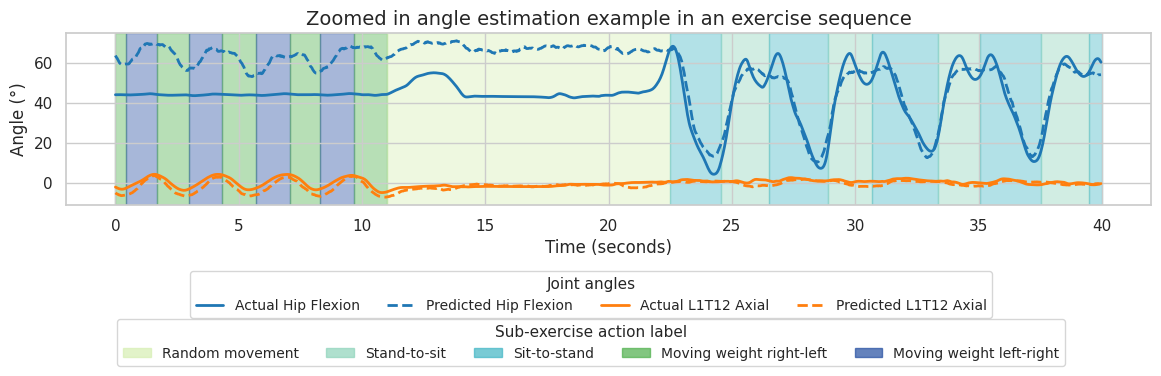

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

# --- Parameters ---
base_dir = "/data/leuven/365/vsc36565/WZC/results"
sampling_frequency = 30
split = 3
method = "videopose"
frame_start, frame_end = 6400, 7600

# Joint selections
hip_joint_id, hip_axis_id = 14, 2     # Left Hip Flexion
l1t12_joint_id, l1t12_axis_id = 0, 1  # L1T12 Axial

# --- Load classification results ---
task = 'class'
class_path = os.path.join(base_dir, task, method, f"{method}_smooth{split}.npy")
class_data = np.load(class_path, allow_pickle=True)
pred_labels, true_labels = get_data(class_data, task=task)

# --- Load regression results ---
task = 'reg'
reg_path = os.path.join(base_dir, task, method, f"{method}_split{split}_win.npy")
reg_data = np.load(reg_path, allow_pickle=True)
pred_reg, true_reg = get_data(reg_data, task=task)

# --- Extract relevant signals ---
actual_labels = true_labels[frame_start:frame_end]
pred_labels = pred_labels[frame_start:frame_end]
time = np.arange(len(actual_labels)) / sampling_frequency

actual_hip = true_reg[frame_start:frame_end, hip_joint_id, hip_axis_id]
pred_hip = pred_reg[frame_start:frame_end, hip_joint_id, hip_axis_id]
actual_l1t12 = true_reg[frame_start:frame_end, l1t12_joint_id, l1t12_axis_id]
pred_l1t12 = pred_reg[frame_start:frame_end, l1t12_joint_id, l1t12_axis_id]

# Label definitions
exercise_labels = {
    0: 'Random movement',
    1: 'Stand-to-sit',
    2: 'Sit-to-stand',
    3: 'Bending forward',
    4: 'Bending bakwards',
    5: 'Moving weight right-left',
    6: 'Moving weight left-right',
    7: 'Lateral leg movement',
    8: 'Lateral leg movement'
}
unique_labels = sorted(set(actual_labels) | set(pred_labels))
cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.2, 0.8, len(unique_labels))))
colors = {label: cmap(i / (len(unique_labels) - 1)) for i, label in enumerate(unique_labels)}
colors[5] ='#4daf4a'

fig, ax = plt.subplots(1, 1, figsize=(14, 4))

def plot_background_labels(ax, labels, colors, sampling_rate, alpha=0.25):
    current_start = 0
    for i in range(len(labels)):
        if i == len(labels) - 1 or labels[i] != labels[i + 1]:
            start_time = current_start / sampling_rate
            end_time = (i + 1) / sampling_rate
            ax.axvspan(start_time, end_time, color=colors[labels[i]], alpha=alpha, zorder=0)
            current_start = i + 1

# Background
alpha_val = 0.4
plot_background_labels(ax, actual_labels, colors, sampling_frequency, alpha=alpha_val)

# Plot joint signals
line1, = ax.plot(time, actual_hip, label="Actual Hip Flexion", color="tab:blue", linewidth=2, linestyle='-')
line2, = ax.plot(time, pred_hip, label="Predicted Hip Flexion", color="tab:blue", linewidth=2, linestyle='--')
line3, = ax.plot(time, actual_l1t12, label="Actual L1T12 Axial", color="tab:orange", linewidth=2, linestyle='-')
line4, = ax.plot(time, pred_l1t12, label="Predicted L1T12 Axial", color="tab:orange", linewidth=2, linestyle='--')

# Axis styling
ax.set_ylabel("Angle (°)", fontsize=12)
ax.set_xlabel("Time (seconds)", fontsize=12)
ax.set_title("Zoomed in angle estimation example in an exercise sequence", fontsize=14)
ax.grid(True)

from matplotlib.legend import Legend

# --- Create handles ---
exercise_handles = [
    Rectangle((0, 0), 1, 1, color=colors[key], alpha=0.7, label=exercise_labels.get(key, 'Unknown'))
    for key in unique_labels
]

line_handles = [
    line1, line2, line3, line4
]
line_labels = [
    "Actual Hip Flexion", "Predicted Hip Flexion",
    "Actual L1T12 Axial", "Predicted L1T12 Axial"
]

# --- Plot exercise label legend ---
exercise_legend = fig.legend(
    handles=exercise_handles,
    loc="lower center",
    ncol=len(exercise_handles),
    fontsize=10,
    title="Sub-exercise action label",
    title_fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, 0.03)
)

# --- Plot joint angle legend ---
angle_legend = fig.legend(
    handles=line_handles,
    labels=line_labels,
    loc="lower center",
    ncol=len(line_handles),
    fontsize=10,
    title="Joint angles",
    title_fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, 0.15)
)

# --- Adjust bottom spacing ---
fig.subplots_adjust(bottom=0.45)
plt.savefig("results/figures/zoomed_reg.svg", format="svg")
plt.show()


Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split0.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split1.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split2.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split3.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split4.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split5.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split6.npy


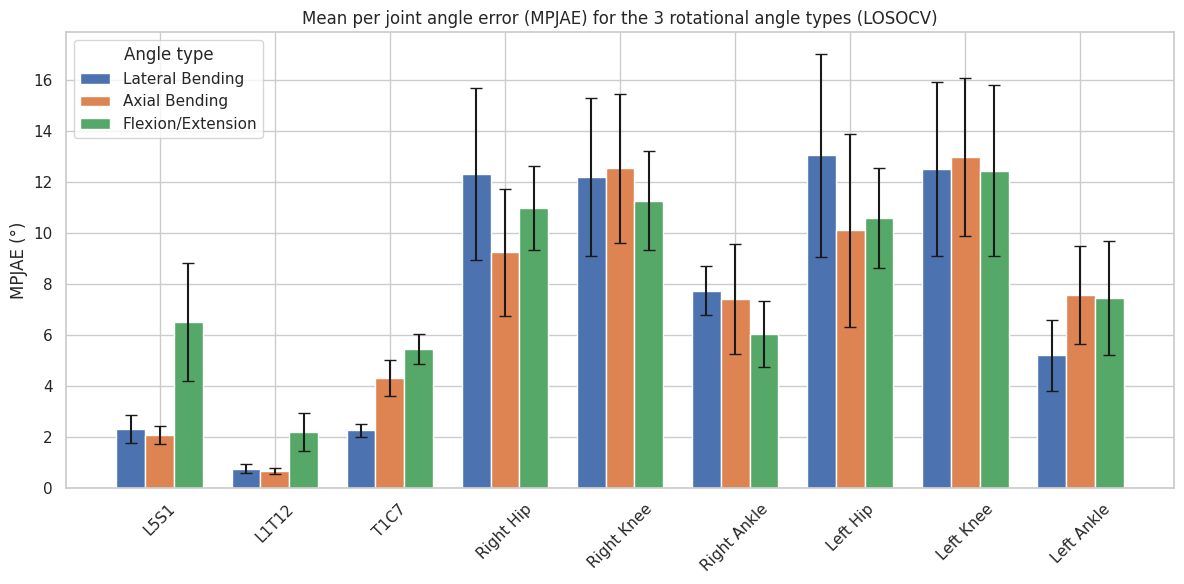

In [12]:

import os
import numpy as np
import matplotlib.pyplot as plt

# Configurations
all_coordinates = ['x', 'z', 'y']
coord_titles_map = {'x': "Lateral Bending", 'z': "Axial Bending", 'y': "Flexion/Extension"}
joint_names = ['L5S1', 'L1T12', 'T1C7', 'Right Hip', 'Right Knee', 'Right Ankle', 'Left Hip', 'Left Knee', 'Left Ankle']
task = 'reg'
method = 'videopose'  # replace with your method name
base_dir = "/data/leuven/365/vsc36565/WZC/results"
splits = list(range(7))  # or whatever splits you have

# Define the reliable joint mask
joint_mask = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=np.float32)
valid_joint_indices = np.where(joint_mask == 1)[0]
# Storage for MAE values
mae_scores_all = []

# Compute MAE per joint and coordinate
for split in splits:
    file_path = os.path.join(base_dir, task, method, f"{method}_split{split}.npy")
    print(f"Loading data from: {file_path}")
    data = np.load(file_path, allow_pickle=True)
    pred, actual = get_data(data, task)

    per_coord_mae = compute_mae_videopose(pred, actual, joint_mask, mode="per_joint_per_coord")
    mae_scores_all.append(per_coord_mae[valid_joint_indices])

mae_scores_all = np.stack(mae_scores_all)  # shape: (n_splits, n_joints, 3)

# Compute mean and std
mae_mean = np.mean(mae_scores_all, axis=0)
mae_std = np.std(mae_scores_all, axis=0)

# Plot: Grouped Bar Chart
x = np.arange(len(joint_names))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, coord in enumerate(all_coordinates):
    offset = (i - 1) * bar_width
    ax.bar(x + offset, mae_mean[:, i], bar_width, yerr=mae_std[:, i],
           label=coord_titles_map[coord], capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(joint_names, rotation=45)
ax.set_ylabel("MPJAE (°)")
# ax.set_xlabel("Axial joints            Lower body joints")
ax.set_title("Mean per joint angle error (MPJAE) for the 3 rotational angle types (LOSOCV)")
ax.legend(title="Angle type")
plt.tight_layout()
plt.savefig("results/figures/mpjae.svg", format="svg")
plt.show()


